## Random Forest com a utilização de EMD (Decomposição em Modos Empíricos)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import os
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from PyEMD import EMD
from scipy.stats import entropy

# Ignorar os avisos (warnings) do MNE para deixar o output mais limpo
warnings.filterwarnings('ignore')

In [2]:
%pip install EMD-signal
%pip install mne-qt-browser PyQt5
mne.viz.set_browser_backend('qt')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Using qt as 2D backend.


In [3]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Deixando as colunas ID com o mesmo tipo
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Unindo as tabelas pelo ID
df_completo = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_completo = pd.merge(df_completo, df_paindetect, on='ID', how='inner')

df_completo = df_completo.dropna(subset=['Actual Pain'])

In [4]:
# Instanciar o modelo EMD
emd = EMD()

# Definir apenas os canais mais relevantes
canais_alvo = ['P7', 'P8', 'C3', 'C4', 'F3', 'F4']
num_imfs_desejados = 4 # Extraindo 4 IMFs

X_emd_features = []
y_labels_emd = []
feature_names_emd = []

pasta_eeg = './cleaned' 

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Gráfico salvo como 'Visualizacao_EMD_Canal_C4.png'!


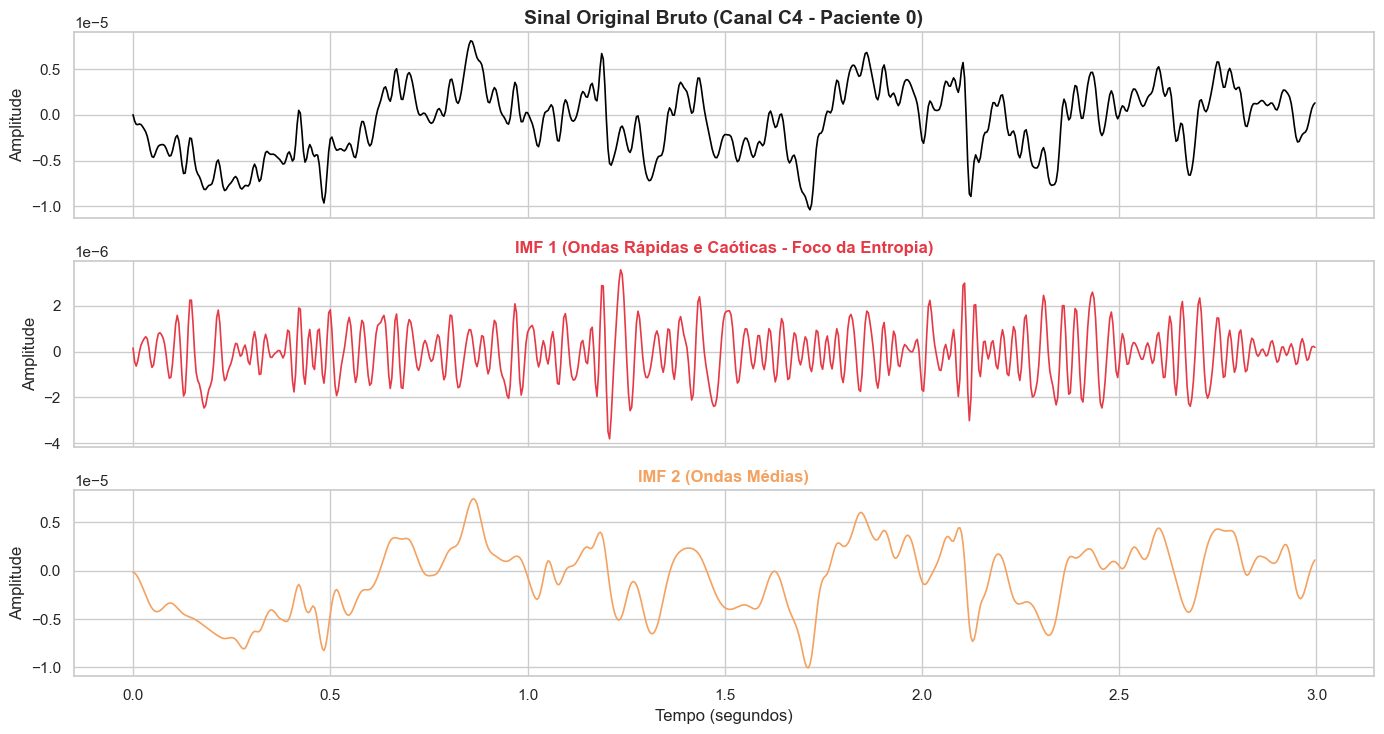

In [14]:
# 1. Escolher a primeira paciente da tabela e o canal de Ouro (C4)
paciente_id = int(float(df_completo.iloc[0]['ID']))
canal_escolhido = 'C4'
caminho = os.path.join(pasta_eeg, f"ID{paciente_id}_preproc_eeg.fif")

if os.path.exists(caminho):
    # 2. Carregar o EEG
    raw = mne.io.read_raw_fif(caminho, preload=True, verbose=False)
    raw.pick_channels([canal_escolhido])
    
    sinal_completo = raw.get_data()[0, :] # Pega o vetor 1D do sinal
    tempo_completo = raw.times
    sfreq = raw.info['sfreq']
    
    # 3. Pegar apenas um trecho de 3 segundos para conseguirmos ENXERGAR as ondas
    amostras_3s = int(3 * sfreq) 
    sinal_trecho = sinal_completo[:amostras_3s]
    tempo_trecho = tempo_completo[:amostras_3s]

    # 4. Rodar o EMD apenas neste trecho
    emd = EMD()
    imfs = emd.emd(sinal_trecho, max_imf=4)

    # 5. Criar a visualização
    num_plots = len(imfs) + 1
    fig, axes = plt.subplots(num_plots, 1, figsize=(14, 2.5 * num_plots), sharex=True)
    sns.set_theme(style="whitegrid")

    # Plot 1: Sinal Original (A Panela de Sopa)
    axes[0].plot(tempo_trecho, sinal_trecho, color='black', linewidth=1.2)
    axes[0].set_title(f"Sinal Original Bruto (Canal {canal_escolhido} - Paciente {paciente_id})", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Amplitude")

    # Plots 2 em diante: As IMFs (As Cascas da Cebola)
    cores = ['#e63946', '#f4a261', '#2a9d8f', '#264653', '#8338ec']
    titulos = [
        "IMF 1 (Ondas Rápidas e Caóticas - Foco da Entropia)",
        "IMF 2 (Ondas Médias)",
        "IMF 3 (Ondas Lentas)",
        "IMF 4 (Ondas Muito Lentas / Resíduo)"
    ]

    for i, imf in enumerate(imfs):
        titulo_imf = titulos[i] if i < len(titulos) else f"IMF {i+1}"
        
        axes[i+1].plot(tempo_trecho, imf, color=cores[i % len(cores)], linewidth=1.2)
        axes[i+1].set_title(titulo_imf, fontsize=12, fontweight='bold', color=cores[i % len(cores)])
        axes[i+1].set_ylabel("Amplitude")

    axes[-1].set_xlabel("Tempo (segundos)", fontsize=12)
    plt.tight_layout()
    
    # Salvar a imagem e mostrar
    plt.savefig("Visualizacao_EMD_Canal_C4.png", dpi=300)
    print("Gráfico salvo como 'Visualizacao_EMD_Canal_C4.png'!")
    plt.show()

else:
    print(f"Arquivo da paciente {paciente_id} não encontrado na pasta {pasta_eeg}.")

In [6]:
for index, row in df_completo.iterrows():
    paciente_id = int(float(row['ID']))
    nota_dor = float(row['Actual Pain'])
    caminho = os.path.join(pasta_eeg, f"ID{paciente_id}_preproc_eeg.fif")
    
    if os.path.exists(caminho):
        try:
            raw = mne.io.read_raw_fif(caminho, preload=True, verbose=False)
            raw.pick_channels(canais_alvo) 
            
            dados = raw.get_data()
            nomes_canais = raw.ch_names
            
            features_paciente = []
            nomes_temporarios = []
            
            # LOOP CANAL POR CANAL 
            for i, canal in enumerate(nomes_canais):
                sinal_canal = dados[i, :]
                
                # O EMD calcula as IMFs
                imfs = emd.emd(sinal_canal, max_imf=num_imfs_desejados)
                
                # LOOP DAS IMFs COM GARANTIA DE TAMANHO (PADDING) 
                for num_imf in range(num_imfs_desejados):
                    
                    # Se o EMD encontrou essa IMF, calcula os dados normalmente
                    if num_imf < len(imfs):
                        imf = imfs[num_imf]
                        
                        energia = np.var(imf)
                        counts, _ = np.histogram(imf, bins=20, density=True)
                        probabilidade = counts / np.sum(counts)
                        entropia_shannon = entropy(probabilidade)
                        
                    # Se o EMD não encontrou, preenche com zero para não dar erro no Numpy
                    else:
                        energia = 0.0
                        entropia_shannon = 0.0
                        
                    # Adiciona as features do paciente
                    features_paciente.append(energia)
                    features_paciente.append(entropia_shannon)
                    
                    if not feature_names_emd:
                        nomes_temporarios.append(f"EMD_{canal}_IMF{num_imf+1}_Energia")
                        nomes_temporarios.append(f"EMD_{canal}_IMF{num_imf+1}_Entropia")
            
            if not feature_names_emd:
                feature_names_emd = nomes_temporarios
                
            X_emd_features.append(features_paciente)
            y_labels_emd.append(nota_dor)
            print(f"[OK] Paciente {paciente_id} decomposto com EMD.")
            
        except Exception as e:
            print(f"[ERRO] Paciente {paciente_id}: {e}")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Paciente 0 decomposto com EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Paciente 1 decomposto com EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Paciente 2 decomposto com EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Paciente 3 decomposto com EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Paciente 4 decomposto com EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Paciente 5 decomposto com EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Paciente 6 decomposto com EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Paciente 7 decomposto com EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pic

In [9]:
# Transforma em Matrizes Numpy
X_emd = np.array(X_emd_features)
y_emd = np.array(y_labels_emd)

print(f"\nExtração EMD Concluída! Formato: {X_emd.shape} (Pacientes x Features EMD)")


Extração EMD Concluída! Formato: (36, 48) (Pacientes x Features EMD)


In [10]:
# Verificando se a matriz do EMD foi criada com sucesso no passo anterior
if 'X_emd' in locals() and X_emd.shape[0] > 0:
    print("Avaliando modelo Random Forest com as features do EMD...")
    
    # Transformar o alvo contínuo em binário (Dor Intensa vs Leve/Mod)
    y_class_emd = np.where(y_emd >= 6, 1, 0)
    
    print(f"\nDistribuição das classes:")
    print(f"- Pacientes com Dor Intensa (>=6): {sum(y_class_emd == 1)}")
    print(f"- Pacientes com Dor Leve/Mod (<6): {sum(y_class_emd == 0)}\n")

    # Vamos selecionar as 5 melhores features de EMD para não causar overfitting
    num_features_selecionar = 5 
    
    # Criando o Pipeline (Padronização -> Seleção -> Random Forest)
    pipeline_emd = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=num_features_selecionar)), 
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42))
    ])
    
    # Validação Cruzada K-Fold Estratificada (5 divisões)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calculando as métricas de performance
    scores_acc = cross_val_score(pipeline_emd, X_emd, y_class_emd, cv=skf, scoring='accuracy')
    scores_auc = cross_val_score(pipeline_emd, X_emd, y_class_emd, cv=skf, scoring='roc_auc')
    
    print("DESEMPENHO DO MODELO DE CLASSIFICAÇÃO (EMD)")
    print(f"Acurácia Média: {scores_acc.mean()*100:.1f}% (Desvio: {scores_acc.std()*100:.1f}%)")
    print(f"AUC-ROC Média: {scores_auc.mean():.3f}")
    
    pipeline_emd.fit(X_emd, y_class_emd)
    
    seletor = pipeline_emd.named_steps['selector']
    mascara = seletor.get_support()
    biomarcadores_finais = np.array(feature_names_emd)[mascara]
    importancias = pipeline_emd.named_steps['rf'].feature_importances_
    
    print(f"\nTOP {num_features_selecionar} BIOMARCADORES EMD (CLASSIFICAÇÃO)")
    for bio, imp in zip(biomarcadores_finais, importancias):
        print(f"- {bio}: {imp*100:.1f}% de importância")

else:
    print("A matriz X_emd não foi encontrada. Rode a célula de extração EMD primeiro!")

Avaliando modelo Random Forest com as features do EMD...

Distribuição das classes:
- Pacientes com Dor Intensa (>=6): 19
- Pacientes com Dor Leve/Mod (<6): 17

DESEMPENHO DO MODELO DE CLASSIFICAÇÃO (EMD)
Acurácia Média: 61.1% (Desvio: 10.6%)
AUC-ROC Média: 0.583

TOP 5 BIOMARCADORES EMD (CLASSIFICAÇÃO)
- EMD_P8_IMF2_Energia: 37.5% de importância
- EMD_P8_IMF4_Energia: 7.5% de importância
- EMD_C4_IMF1_Entropia: 42.6% de importância
- EMD_C4_IMF4_Energia: 6.6% de importância
- EMD_C4_IMF4_Entropia: 5.9% de importância
